Analiza cen nieruchomości (California Housing)
Dane poprzez EDA (Exploratory Data Analysis), preprocessing: skalowanie, model ML (regresja liniowa).


Cel: Przewidywanie mediany cen domów w dzielnicach Kalifornii na podstawie cech takich jak dochód mieszkańców, wiek domów czy liczba pokoi.

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

 Dane 
(20640, 10)

 Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex

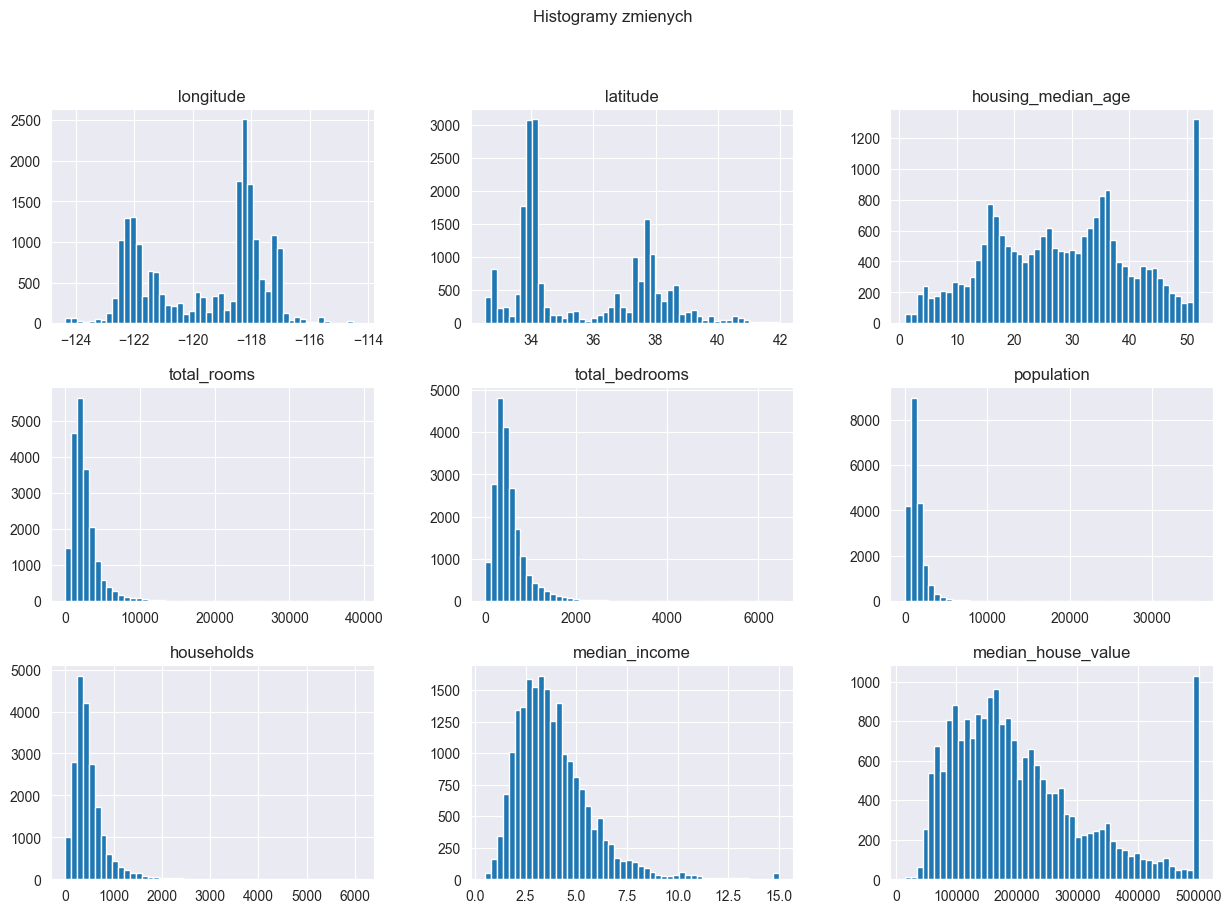

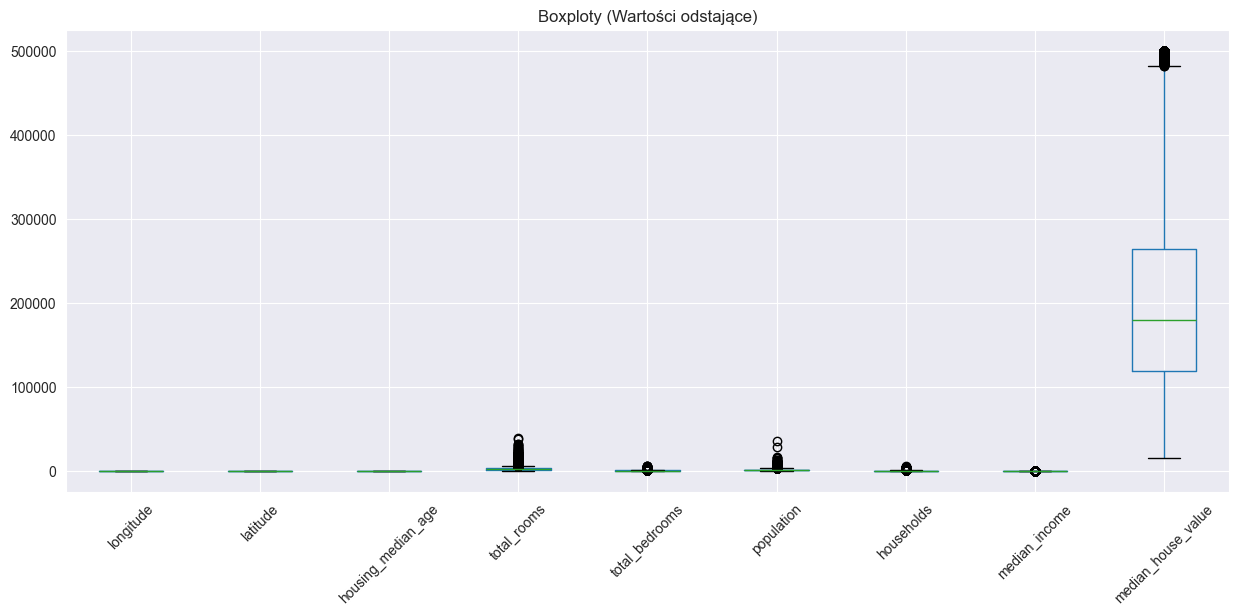

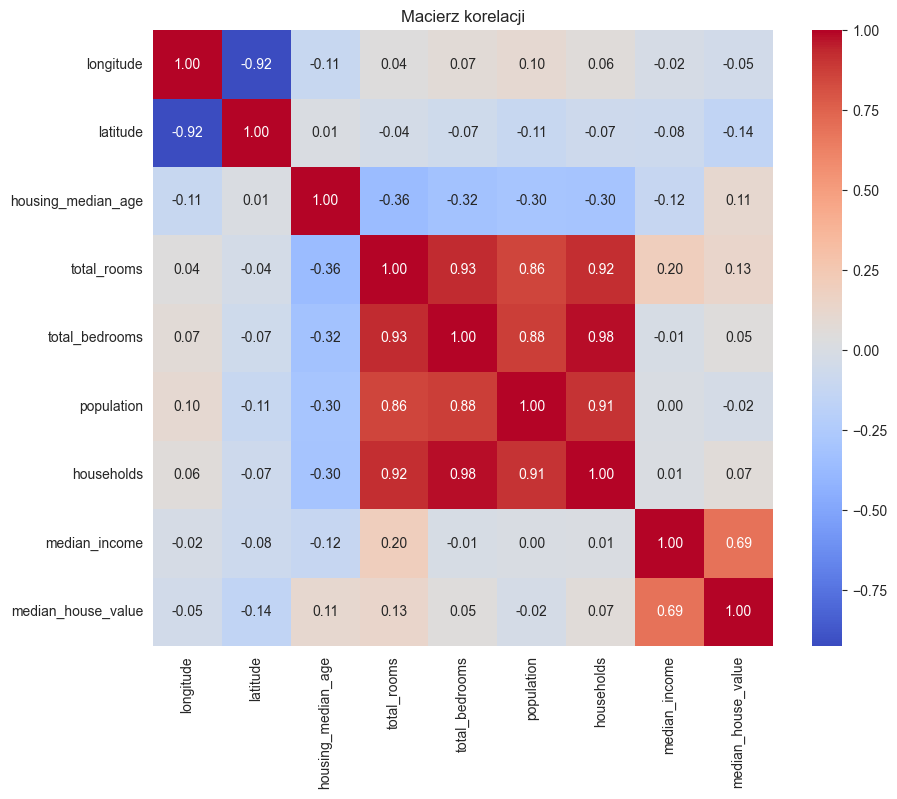


Liczba braków w 'total_bedrooms' po naprawie: 0

Pierwsze wiersze po zakodowaniu zmiennych tekstowych:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value  \
0       322.0       126.0         8.3252            452600.0   
1      2401.0      1138.0         8.3014            358500.0   
2       496.0       177.0         7.2574            352100.0   
3       558.0       219.0         5.6431            341300.0   
4       565.0       259.0         3.8462            342200.0   

   ocean_proximity_INLAND  ocean_proximity_ISLAND  ocean_pro

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


df = pd.read_csv("housing.csv")

print(df.head())

print("\n Dane ")
print(df.shape)

print("\n Info")
print(df.info())

print("\n Statystyki ")
print(df.describe().T)

print("\n Braki ")
print(df.isna().sum())


numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols].hist(bins=50, figsize=(15, 10))
plt.suptitle("Histogramy zmienych")
plt.show()


plt.figure(figsize=(15, 6))
df.boxplot(column=list(numeric_cols), rot=45)
plt.title("Boxploty (Wartości odstające)")
plt.show()


plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Macierz korelacji")
plt.show()


data = df.copy()


median_bedrooms = data['total_bedrooms'].median()
data['total_bedrooms'] = data['total_bedrooms'].fillna(median_bedrooms)
print(f"\nLiczba braków w 'total_bedrooms' po naprawie: {data['total_bedrooms'].isna().sum()}")


data_encoded = pd.get_dummies(data, columns=['ocean_proximity'], drop_first=True)
print("\nPierwsze wiersze po zakodowaniu zmiennych tekstowych:")
print(data_encoded.head())


target_col = "median_house_value"
X = data_encoded.drop(target_col, axis=1)
y = data_encoded[target_col]

print(f"\nWymiary X: {X.shape}, Wymiary y: {y.shape}")


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


reg_model = LinearRegression()
reg_model.fit(X_train, y_train)


y_pred = reg_model.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n Wyniky Regresji ")
print(f"MSE (Blad sredniokwadratowy): {mse:.2f}")
print(f"MAE (Sredni blad bezwzgledny): {mae:.2f}")
print(f"R2 Score (Ile % zmiennosci wyjasnia model): {r2:.4f}")

Podsumowanie

1.Analiza danych:
`housing.csv` zawierającym 20,640 obserwacji.
Braki danych: Zidentyfikowano 207 brakujących wartości w kolumnie `total_bedrooms`. Zostały one uzupełnione medianą.


2.Modelowanie:
Wybrano model Regresji Liniowej, ponieważ przewidywaliśmy ciągłą wartość ceny (`median_house_value`).
Zastosowano skalowanie danych (`StandardScaler`), co jest kluczowe dla poprawności działania regresji liniowej przy cechach o różnych rzędach wielkości (np. dochód vs populacja).

3.Wyniki:
Model osiągnął współczynnik determinacji R² na poziomie ok. 0.63. Oznacza to, że nasz model wyjaśnia około 63% zmienności cen nieruchomości.
Analiza korelacji wykazała, że największy pozytywny wpływ na cenę ma `median_income` (dochód mieszkańców), co potwierdza intuicję ekonomiczną.
